In [5]:
import os
import sys
from pathlib import Path

import numpy as np
import random
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_models import build_model_catalog
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals
from Training.data.python.Modules.PDESolver_1D import PDE_RHS_1D, PDE_sim_1d

PATHS = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = PATHS.project_root
TRAINING_ROOT = PATHS.training_root
JN_ROOT = PATHS.notebook_root
DATA_ROOT = PATHS.data_root
BINN_ROOT = PATHS.binn_root

register_notebook_pickle_globals()

data_orig_obj_FKPP = load_original_data(DATA_ROOT)

from paper_helpers import (
    scale_function_by_percent_error,
    plot_diff_mse_lst,
    plot_diffusion_across_epochs,
    plot_final_loss_lst,
    plot_growth_across_epochs,
    plot_initial_condition_1d,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_MSE_grow_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
    plot_running_min_loss_components_broken_x_log_lst,
    plot_running_min_loss_components_seed_broken_x_log_lst,
    plot_smoothed_loss_components_seed_broken_x_log_lst,
    plot_total_run_times_lst,
    plot_adam_D_diagnostics,
)


## Load the shared data

The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462).


MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


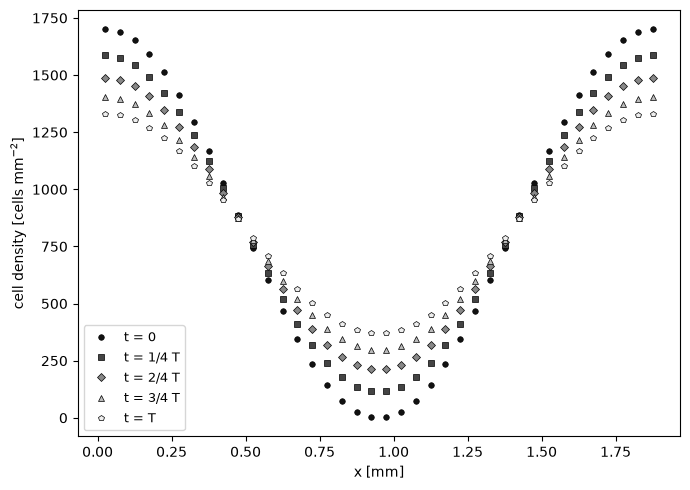

In [6]:
# Load the shared spatial and temporal coordinates from Lagergren et al. (2020).
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1

# Shared data-object catalogue used by this notebook.
data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

xNum = len(x)
tNum = len(t)
gamma = 0
noise_percent = 0
IC_label = "cos"
seed = 0
dataX2num = 1

data_info = {
    "dataX1num": xNum,
    "dataX2num": dataX2num,
    "dataTnum": tNum,
    "dataK": K,
    "dataICLabel": IC_label,
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": gamma,
    "dataNoisePercent": noise_percent,
    "dataNoiseSeed": seed,
}

data_obj, data_df_updated = load_data_object(data_info, DATA_ROOT, data_df=data_df)
plot_initial_condition_1d(data_obj)




In [7]:
def diffusion_func(u):
    return 0.02472 * np.ones_like(u)


def growth_func(u):
    return 0.0 * u


def ic1(x):
    mean_x = np.mean(x)
    L = np.max(x) - np.min(x)
    return 0.5 - 0.5 * np.cos(2 * np.pi * (x - mean_x) / L)


def ic2(x):
    mean_x = np.mean(x)
    L = np.max(x) - np.min(x)
    return 0.5 + 0.5 * np.cos(2 * np.pi * (x - mean_x) / L)


def RDEq(x, t, u0, clear, PDE_sim_1d, PDE_RHS_1D):
    ic_interp = lambda x_query: np.interp(x_query, x, u0)
    return PDE_sim_1d(
        PDE_RHS_1D, ic_interp, x, t,
        diffusion_func, growth_func, clear=clear
    )


def maybe_add_noise(u_clean, noise_lvl=0, seed=42):
    if noise_lvl == 0:
        return np.array(u_clean, copy=True)

    rng = np.random.default_rng(seed)
    noise_scale = noise_lvl / 100.0
    noisy = u_clean * (1.0 + rng.normal(loc=0.0, scale=noise_scale, size=u_clean.shape))
    return np.clip(noisy, 0.0, None)


def TVplotter_lines_and_hist(
    data_obj,
    PDE_sim_1d,
    PDE_RHS_1D,
    ic_num=1,
    seed=42,
    bins=7,
    tnum=5,
    xnum=10,
    noise_lvl=0,
    save_path_intro="pngs/",
    dpi=100,
    color_scheme="green",
    marker_size=8,
    axis_label_fontsize=15,
    axis_tick_fontsize=15,
    legend_fontsize=14,
):
    ic_func = ic1 if ic_num == 1 else ic2

    x = np.linspace(np.min(data_obj.x), np.max(data_obj.x), xnum)
    t = np.linspace(np.min(data_obj.t), np.max(data_obj.t), tnum)

    K = data_obj.K
    u_clean = RDEq(
        x=x,
        t=t,
        u0=K * ic_func(x),
        clear=False,
        PDE_sim_1d=PDE_sim_1d,
        PDE_RHS_1D=PDE_RHS_1D,
    )

    cell_density = maybe_add_noise(u_clean, noise_lvl=noise_lvl, seed=seed)


    num_x, num_t = len(x), len(t)
    total_cells = num_x * num_t
    num_purple = int(0.2 * total_cells)

    random.seed(seed)
    purple_cells = random.sample(
        [(i, j) for i in range(num_x) for j in range(num_t)],
        num_purple,
    )

    fig1, ax_line = plt.subplots(figsize=(7, 5))

    if color_scheme.lower() == "green":
        cmap = plt.cm.Greens
    elif color_scheme.lower() == "blue":
        cmap = plt.cm.Blues
    else:
        raise ValueError("color_scheme must be 'green' or 'blue'")

    colors = cmap(np.linspace(0.4, 0.9, num_t))

    for j, (tj, c) in enumerate(zip(t, colors)):
        ax_line.plot(
            x,
            cell_density[:, j],
            color=c,
            linewidth=0.5,
            marker="o",
            markersize=marker_size,
            markerfacecolor=c,
            markeredgecolor="black",
            markeredgewidth=0.5,
            label=f"t = {tj:.0f} days",
        )

    first_val_point = True
    for i, j in purple_cells:
        label = "validation points" if first_val_point else "_nolegend_"
        ax_line.scatter(
            x[i],
            cell_density[i, j],
            facecolors="none",
            edgecolors="red",
            lw=2,
            s=marker_size ** 2,
            zorder=3,
            label=label,
        )
        first_val_point = False

    ax_line.set_xlabel("x [mm]", fontsize=axis_label_fontsize)
    ax_line.set_ylabel("Density [a.u.]", fontsize=axis_label_fontsize)
    ax_line.tick_params(axis="both", labelsize=axis_tick_fontsize)
    ax_line.legend(frameon=False, fontsize=legend_fontsize)

    plt.tight_layout()
    if save_path_intro:
        plt.savefig(f"{save_path_intro}/ic{ic_num}_{seed}_lineplot.png", dpi=dpi)
    plt.show()
    fig2, ax_hist = plt.subplots(figsize=(7, 5))

    all_vals = cell_density.ravel()
    purple_vals = np.array([cell_density[i, j] for i, j in purple_cells])
    edges = np.linspace(0, 1, bins + 1)

    counts_all, _ = np.histogram(all_vals, bins=edges)
    counts_val, _ = np.histogram(purple_vals, bins=edges)

    base_color = plt.cm.Greens(0.6) if color_scheme == "green" else plt.cm.Blues(0.6)

    ax_hist.barh(
        edges[:-1],
        counts_all,
        align="edge",
        height=np.diff(edges),
        color=base_color,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85,
        label="training",
    )

    ax_hist.barh(
        edges[:-1],
        counts_val,
        align="edge",
        height=np.diff(edges),
        color="r",
        edgecolor="black",
        linewidth=0.4,
        alpha=0.9,
        label="validation",
    )

    ax_hist.set_xlabel("Count", fontsize=axis_label_fontsize)
    ax_hist.set_ylabel("Density [a.u.]", fontsize=axis_label_fontsize)
    ax_hist.tick_params(axis="both", labelsize=axis_tick_fontsize)
    ax_hist.set_ylim(0, 1)
    ax_hist.legend(frameon=False, fontsize=legend_fontsize, bbox_to_anchor=(0.6, 0.5))

    plt.tight_layout()
    if save_path_intro:
        plt.savefig(f"{save_path_intro}/ic{ic_num}_{seed}_histogram.png", dpi=dpi)
    plt.show()


Progress: 100.00% complete


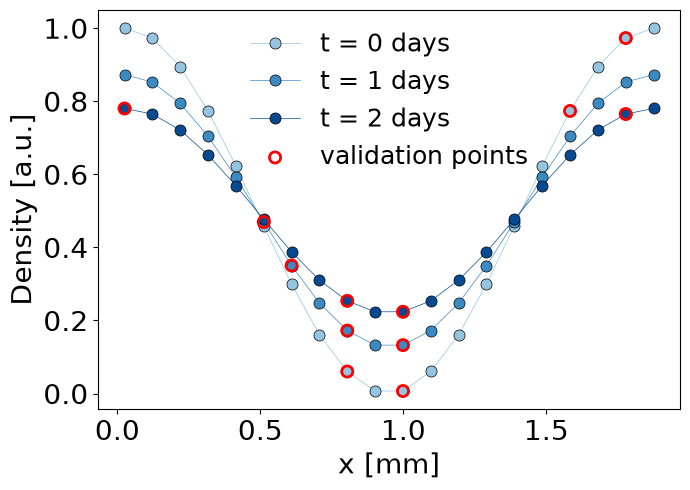

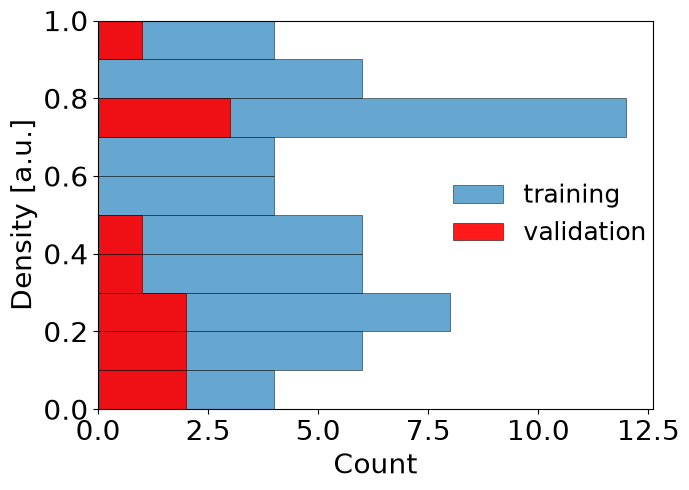

Progress: 100.00% complete


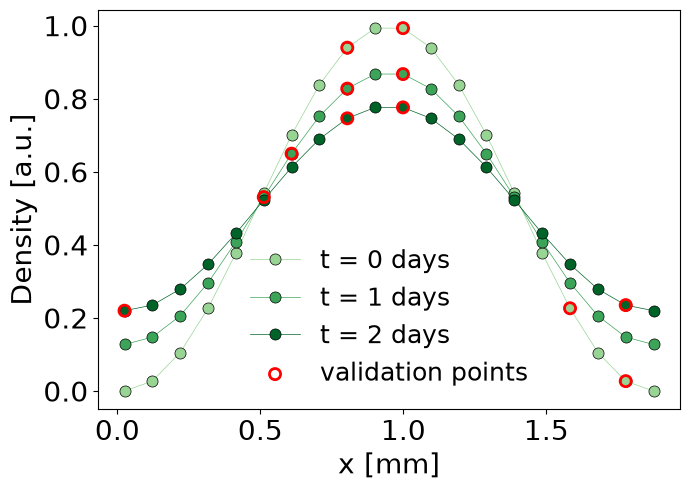

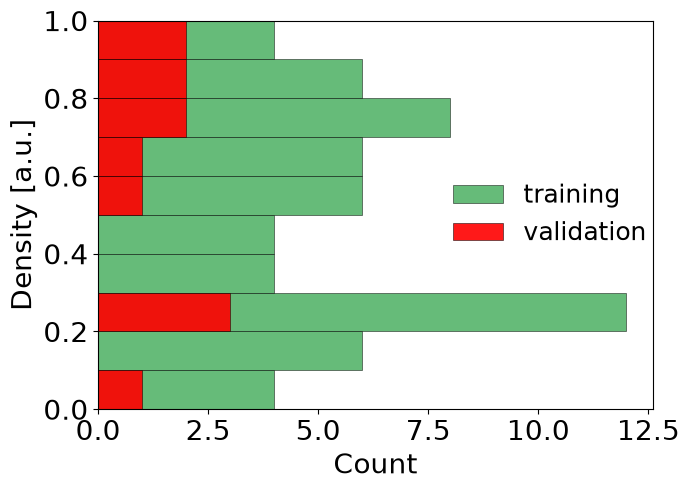

Progress: 100.00% complete


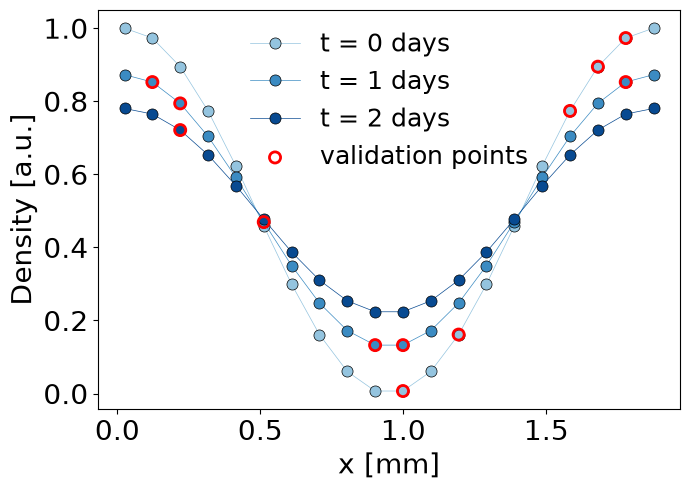

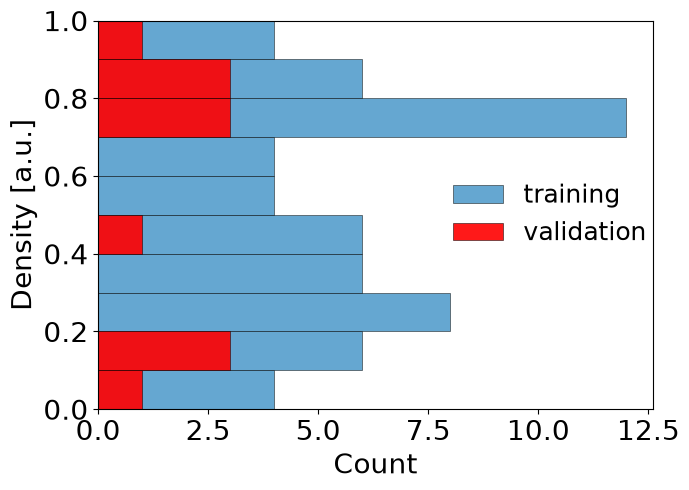

Progress: 100.00% complete


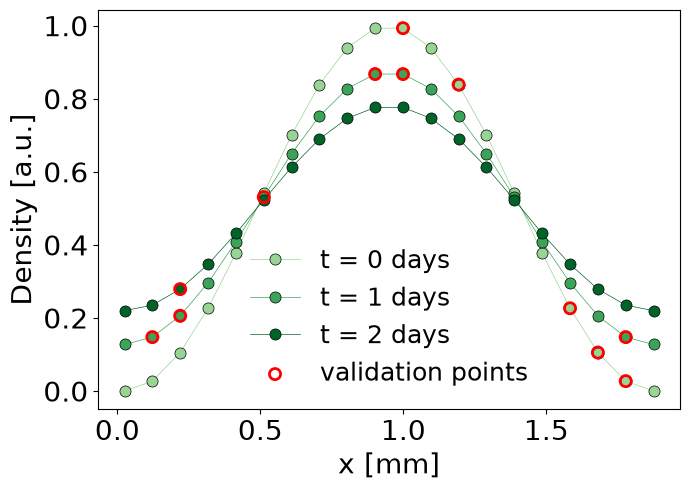

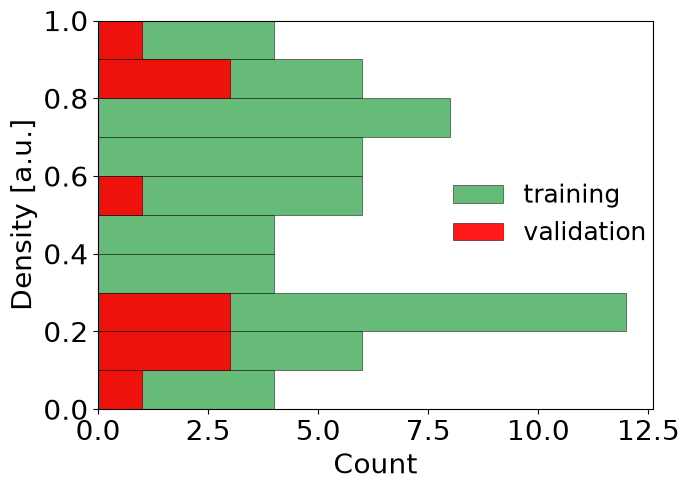

In [8]:
# ==================== Plot TV split figure ====================
name_intro = "pngs/TVsplit/"
os.makedirs(name_intro, exist_ok=True)
for seed in [0,1]:
    for ic_num in [1,2]:
        if ic_num == 1:
            color_scheme = "blue"
        else:
            color_scheme = "green"

        TVplotter_lines_and_hist(data_obj,
                PDE_sim_1d, 
                PDE_RHS_1D, 
                ic_num=ic_num,
                tnum=3,
                xnum=20,
                bins=10,
                save_path_intro = name_intro,
                dpi=100,
                seed=seed,
                color_scheme=color_scheme,
                axis_label_fontsize=20,
                axis_tick_fontsize=20,
                legend_fontsize=18
                )

## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
